## NB04 — Inter-model statistics and Grad-CAM

This notebook has two halves.

**Part A, inter-model statistics.** DeLong's test (on ROC-AUCs) and McNemar's
exact test (on 0.5-threshold predictions) comparing the three architectures,
per attack class. Both are deterministic paired tests with no randomness, so
this half is **recomputed live** from the frozen per-sample score files
`checkpoints/scores_test_{resnet50,densenet121,vit}.csv`. All logic is copied
verbatim from `src/compare_models.py`.

**Part B, Grad-CAM.** Three saved overlays for ResNet50, with the generating
code from `src/gradcam.py` shown for reference. The overlays are **loaded from
disk**, not regenerated: producing them rebuilds the model and runs gradients on
a GPU, which cannot run on a login node or in a marker's read-only pass. The
exemplar manifest `checkpoints/gradcam_exemplars.csv` pins each overlay to a
specific test sample, so the choice of exemplars is auditable.

## Part A — Inter-model statistics

### Why these two tests, and not a t-test

There is one training run per architecture. With a single run there is no
sampling distribution across runs to test against, so a t-test over the three
runs is not reported. The two tests below instead exploit the fact that all
three models are scored on the **same** test samples, which is what DeLong and
McNemar are built for.

- **DeLong** tests whether two ROC-AUCs measured on the same samples differ. It
  is threshold-independent and matches the ranking finding directly.
- **McNemar (exact)** tests whether two classifiers disagree asymmetrically on
  the same samples at a fixed 0.5 threshold. It is a secondary,
  threshold-dependent error-agreement check.

The logic below is verbatim from `src/compare_models.py`.

In [1]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import binomtest, norm
from sklearn.metrics import roc_auc_score

MODELS = {
    "ResNet50":    "checkpoints/scores_test_resnet50.csv",
    "DenseNet121": "checkpoints/scores_test_densenet121.csv",
    "ViT-B/16":    "checkpoints/scores_test_vit.csv",
}

In [2]:
# ---- DeLong (fast, Sun & Xu 2014) ----------------------------------------
def _compute_midrank(x):
    J = np.argsort(x)
    z = x[J]
    n = len(x)
    t = np.zeros(n, dtype=float)
    i = 0
    while i < n:
        j = i
        while j < n and z[j] == z[i]:
            j += 1
        t[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    tout = np.empty(n, dtype=float)
    tout[J] = t
    return tout


def _fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive = predictions_sorted_transposed[:, :m]
    negative = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]
    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = _compute_midrank(positive[r, :])
        ty[r, :] = _compute_midrank(negative[r, :])
        tz[r, :] = _compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov


def _calc_pvalue(aucs, sigma):
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    z = float(z.item())
    p = float(2 * (1 - norm.cdf(z)))
    return z, p


def delong_test(y_true, score_a, score_b):
    """Two-sided DeLong test that AUC_a == AUC_b on the same samples.
    Returns (auc_a, auc_b, z, p). y_true is 1 for positive (forged), 0 for
    bonafide. Higher score = more forged.
    """
    order = (-y_true).argsort()
    label_1_count = int(y_true.sum())
    preds = np.vstack((score_a, score_b))[:, order]
    aucs, cov = _fast_delong(preds, label_1_count)
    z, p = _calc_pvalue(aucs, cov)
    return float(aucs[0]), float(aucs[1]), z, p

In [3]:
# ---- McNemar (exact binomial) --------------------------------------------
def mcnemar_exact(correct_a, correct_b):
    """McNemar exact test on paired boolean correctness arrays.
    b = A right & B wrong; c = A wrong & B right. Under the null the split
    of the b+c discordant pairs is Binomial(p=0.5). Returns (b, c, p).
    """
    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    n = b + c
    if n == 0:
        return b, c, 1.0
    p = binomtest(min(b, c), n, 0.5, alternative="two-sided").pvalue
    return b, c, float(p)


# ---- selectors -----------------------------------------------------------
def load_scores():
    return {m: pd.read_csv(path) for m, path in MODELS.items()}


def subset_vs_bonafide(df, attack):
    """Rows for one attack type plus all bonafide, as (y_true, p_forged),
    sorted by idx so the three models align sample-for-sample."""
    bona = df[df["y_true"] == 0]
    forged = df[(df["y_true"] == 1) & (df["attack_type"] == attack)]
    sub = pd.concat([bona, forged]).sort_values("idx")
    return sub["y_true"].to_numpy(), sub["p_forged"].to_numpy()

In [4]:
def run_class(data, label, selector):
    print(f"=== {label} ===")
    arrays = {}
    for model, df in data.items():
        y, p = selector(df)
        arrays[model] = (y, p)
        auc = roc_auc_score(y, p)
        print(f"{model}: n={len(y)}, AUC={auc:.4f}")
    print("-- DeLong (AUC vs AUC) --")
    for a, b in itertools.combinations(MODELS, 2):
        ya, pa = arrays[a]
        # both models share the same sample set per class, so y is identical
        auc_a, auc_b, z, p = delong_test(ya, pa, arrays[b][1])
        print(f"{a} vs {b}: AUC {auc_a:.4f} vs {auc_b:.4f}, z={z:.3f}, p={p:.4f}")
    print("-- McNemar exact (0.5-threshold predictions) --")
    for a, b in itertools.combinations(MODELS, 2):
        ya, pa = arrays[a]
        yb, pb = arrays[b]
        ca = (pa >= 0.5).astype(int) == ya
        cb = (pb >= 0.5).astype(int) == yb
        nb, nc, p = mcnemar_exact(ca, cb)
        print(f"{a} vs {b}: b={nb}, c={nc}, p={p:.4f}")
    print()


data = load_scores()
run_class(data, "FACE vs bonafide", lambda df: subset_vs_bonafide(df, "face"))
run_class(data, "TEXT vs bonafide", lambda df: subset_vs_bonafide(df, "text"))

=== FACE vs bonafide ===
ResNet50: n=450, AUC=0.9145
DenseNet121: n=450, AUC=0.8872
ViT-B/16: n=450, AUC=0.7740
-- DeLong (AUC vs AUC) --


ResNet50 vs DenseNet121: AUC 0.9145 vs 0.8872, z=2.391, p=0.0168
ResNet50 vs ViT-B/16: AUC 0.9145 vs 0.7740, z=6.631, p=0.0000
DenseNet121 vs ViT-B/16: AUC 0.8872 vs 0.7740, z=6.088, p=0.0000
-- McNemar exact (0.5-threshold predictions) --
ResNet50 vs DenseNet121: b=43, c=57, p=0.1933
ResNet50 vs ViT-B/16: b=80, c=70, p=0.4625
DenseNet121 vs ViT-B/16: b=68, c=44, p=0.0293

=== TEXT vs bonafide ===
ResNet50: n=1235, AUC=0.1365
DenseNet121: n=1235, AUC=0.1566
ViT-B/16: n=1235, AUC=0.1950
-- DeLong (AUC vs AUC) --
ResNet50 vs DenseNet121: AUC 0.1365 vs 0.1566, z=1.837, p=0.0661
ResNet50 vs ViT-B/16: AUC 0.1365 vs 0.1950, z=3.955, p=0.0001
DenseNet121 vs ViT-B/16: AUC 0.1566 vs 0.1950, z=2.773, p=0.0056
-- McNemar exact (0.5-threshold predictions) --
ResNet50 vs DenseNet121: b=69, c=81, p=0.3692
ResNet50 vs ViT-B/16: b=91, c=131, p=0.0087
DenseNet121 vs ViT-B/16: b=66, c=94, p=0.0325



### OVERALL block (pooled, shown for transparency only)

The comparison below pools all 1385 test samples regardless of attack type. It
is included for completeness and to make the pooling artefact visible, not as a
headline result. Because the pool is dominated by text-edit forgeries on which
every model ranks below chance, the pooled AUCs sit well under 0.5, and the
pooled comparison mixes the recoverable face signal with the inverted text
signal. The per-class blocks above are the interpretable comparison; this pooled
block is exactly the regime the per-attack decomposition exists to avoid.

In [5]:
run_class(data, "OVERALL (all 1385 samples)",
          lambda df: (df["y_true"].to_numpy(), df["p_forged"].to_numpy()))

=== OVERALL (all 1385 samples) ===
ResNet50: n=1385, AUC=0.2441
DenseNet121: n=1385, AUC=0.2576
ViT-B/16: n=1385, AUC=0.2750
-- DeLong (AUC vs AUC) --
ResNet50 vs DenseNet121: AUC 0.2441 vs 0.2576, z=1.367, p=0.1717
ResNet50 vs ViT-B/16: AUC 0.2441 vs 0.2750, z=2.202, p=0.0277
DenseNet121 vs ViT-B/16: AUC 0.2576 vs 0.2750, z=1.349, p=0.1774
-- McNemar exact (0.5-threshold predictions) --
ResNet50 vs DenseNet121: b=80, c=81, p=1.0000
ResNet50 vs ViT-B/16: b=120, c=132, p=0.4884
DenseNet121 vs ViT-B/16: b=90, c=101, p=0.4694



### Reading Part A

On the **face** class the AUC ranking is ResNet50 above DenseNet121 above
ViT-B/16, and DeLong finds every pairwise difference significant at the 0.05
level. This establishes a real architecture ordering for the recoverable
face-swap signal, not a chance ranking. McNemar on the same face pairs is not
uniformly significant, which is expected: it tests error agreement at a single
0.5 threshold rather than the full ranking, and the two tests answer different
questions. The claim that every pairwise difference is significant holds for
**DeLong on the face class**, and is not extended to McNemar or to the text
class.

On the **text** class the models are separable by DeLong in places, but every
model sits below the 0.5 diagonal, so these are comparisons between degrees of
inversion, not between working detectors. A significant DeLong result here says
one model inverts more sharply than another, not that either detects text
manipulation.

The claim supported is specific to the model class under test: off-the-shelf,
whole-image, ImageNet-pretrained classifiers invert on text manipulation, and
the architecture that inverts least still inverts. It is not a claim that text
manipulation is universally undetectable.

## Part B — Grad-CAM

### Exemplar provenance

Three exemplars were selected and pinned in
`checkpoints/gradcam_exemplars.csv`. Every heatmap targets the **forged class**,
so each answers the same question: where does the model look for evidence of
forgery? Holding the target constant is what makes the three overlays
comparable.

The manifest is loaded and shown below. Note that `missed_text` (idx 237) and
`genuine` (idx 1256) are the **same base document**: the same
`chinese2-flickr...48677929383` image, once with a TextDiffuser text
manipulation applied and once clean. Their overlays therefore form a
single-variable comparison, the only change being the presence or absence of the
text edit.

In [6]:
manifest = pd.read_csv("checkpoints/gradcam_exemplars.csv")
manifest[["name", "idx", "attack_type", "y_true", "p_forged", "rel_path"]]

,name,idx,attack_type,y_true,p_forged,rel_path
0,caught_face,0,face,1,1.0,test/attack/facedancer/huawei/netherland-flick...
1,missed_text,237,text,1,0.0,test/attack/textdiffuserft_bfei/iphone15/chine...
2,genuine,1256,none,0,0.0,test/bonafide/iphone15/chinese2-flickr_F_48677...


### Generating code (from `src/gradcam.py`, shown for reference, not run here)

The overlay generation is a GPU job that rebuilds the ResNet50 checkpoint and
runs Grad-CAM through the real model, targeting the forged class. It is shown
here for the record and is not executed in this notebook. The cell below is a raw
cell, so the marker sees the method without the notebook attempting to load torch
or a checkpoint.

### The three overlays

Loaded from `results/gradcam/`. Read left to right as a controlled sequence.

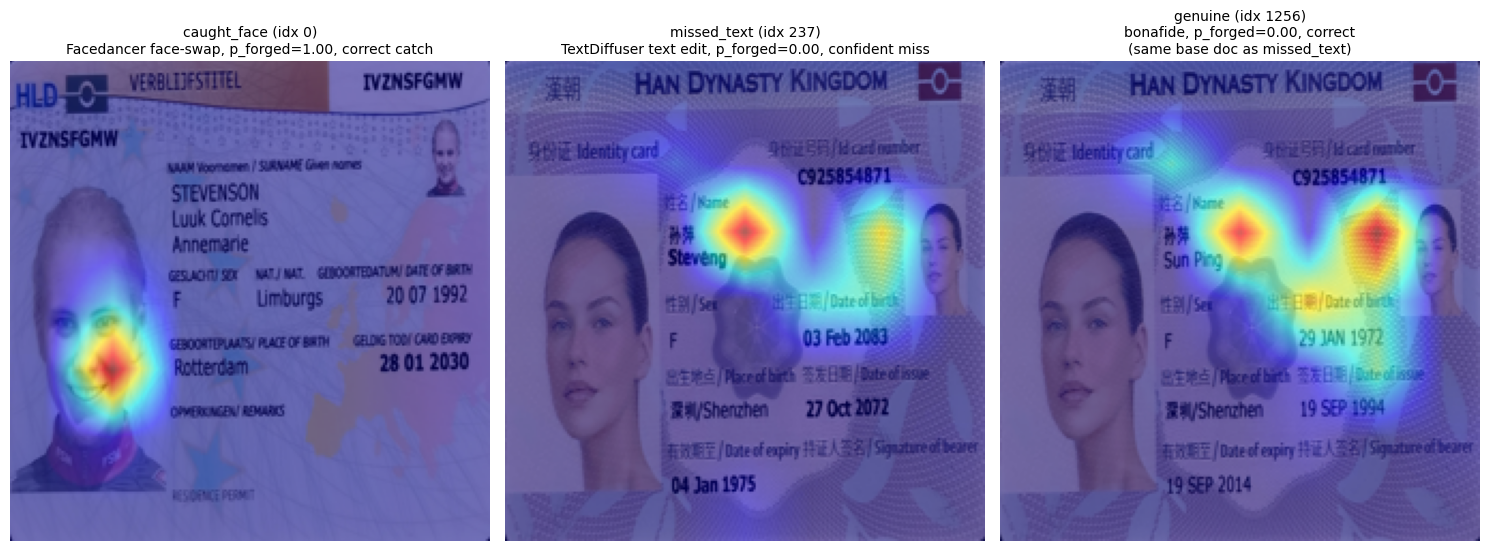

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

panels = [
    ("results/gradcam/gradcam_caught_face.png",
     "caught_face (idx 0)\nFacedancer face-swap, p_forged=1.00, correct catch"),
    ("results/gradcam/gradcam_missed_text.png",
     "missed_text (idx 237)\nTextDiffuser text edit, p_forged=0.00, confident miss"),
    ("results/gradcam/gradcam_genuine.png",
     "genuine (idx 1256)\nbonafide, p_forged=0.00, correct\n(same base doc as missed_text)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, (path, title) in zip(axes, panels):
    ax.imshow(mpimg.imread(path))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Reading Part B

**caught_face is a positive control, and a cautionary one.** The model scores
this face-swap forgery at p_forged = 1.00, a correct and confident catch. But
the heatmap does not fall on the swapped face. It concentrates on the text block.
The model reaches the right answer for this image without localising the actual
manipulated region. This overlay is shown to confirm that Grad-CAM is working
and that attention is legible, not to claim the model attends to the face.

**missed_text and genuine are the single-variable comparison.** These are the
same base document, one carrying a TextDiffuser text edit and one clean. The
model scores both at p_forged = 0.00. Targeting the forged class in both cases,
the attention pattern is essentially unchanged between the manipulated and clean
versions: the heatmap does not move to the edited text field when the edit is
present. The visual evidence lines up with the quantitative finding. On text
manipulation the model's attention does not land on the manipulated region, and
the manipulation does not register.

Grad-CAM here is illustrative support for the inversion result, shown on three
hand-selected and manifest-pinned exemplars. It is not offered as quantitative
evidence in its own right.